In [7]:
import pickle
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from tqdm.auto import tqdm

from IPDiff.utils.visualize import visualize_protein_ligand
import IPDiff.utils.transforms as trans
from IPDiff.utils import reconstruct
from IPDiff.utils import misc

with open(os.path.join(root_dir, 'nohup_outputs/nohup_postprocess_250404_0033.out'), 'r') as f:
    lines = f.readlines()

tranches = []
for line in lines:
    if 'searching for' in line:
        tranches.append(line[-6:-4])


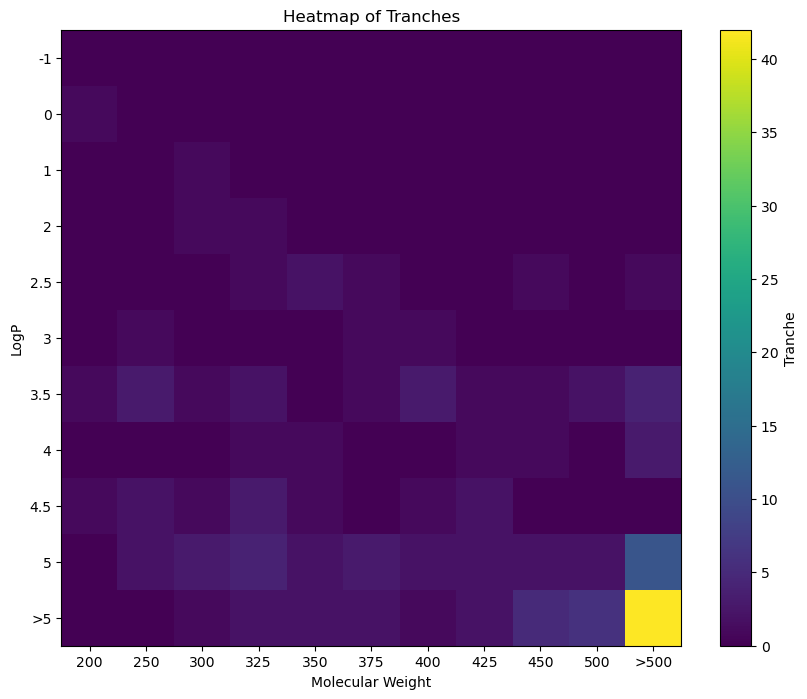

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Convert tranches to numeric values
str2int = {
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10,
}
heats = np.zeros((11, 11))
for t in tranches:
    heats[str2int[t[0]], str2int[t[1]]] += 1

# Create a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(heats, cmap='viridis', aspect='auto')
plt.colorbar(label='Tranche')
plt.xlabel('Molecular Weight')
plt.ylabel('LogP')
plt.xticks(range(11), [200, 250, 300, 325, 350, 375, 400, 425, 450, 500, '>500'])
plt.yticks(range(11), [-1, 0, 1, 2, 2.5, 3, 3.5, 4, 4.5, 5, '>5'])
plt.title('Heatmap of Tranches')
plt.show()
